## Notebook 6: AC Adaptation

In [3]:
# Repo-root discovery + import of cityheat
import sys
from pathlib import Path

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError("Could not find repo root with 'cityheat' and 'configs' folders.")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
C = bootstrap("Rome")  # switch to "Barcelona" later

PROJECT, CITY, CFG, cfg = C["PROJECT"], C["CITY"], C["CFG"], C["cfg"]
OUT, INT, BASE = C["OUT"], C["INT"], C["BASE"]
p_LCZ, p_UrbClim, p_GVI, p_CoolEff = C["p_LCZ"], C["p_UrbClim"], C["p_GVI"], C["p_CoolEff"]

print("Repo root:", ROOT)
print("✔ Loaded config:", CFG)
print("→ Outputs:", OUT)
print("→ Data base:", BASE)

Repo root: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat
✔ Loaded config: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/configs/rome.yml
→ Outputs: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome
→ Data base: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome


**Loading from before**

In [25]:
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.transform import array_bounds

# from earlier notebooks
tmpl_path = INT / "template_ref.tif"   # reference WBGT grid (same as NB5)
mask_tif  = INT / "city_mask.tif"      # boolean mask on that grid
fua_gp    = OUT / "rome_fua.gpkg"      # saved in NB2 under layer="fua"

# loading ref grid + mask
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# loading FUA
assert fua_gp.exists(), f"Missing {fua_gp} (re-run NB2)."
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")  # WGS84 for any lon/lat ops

print("WBGT grid:", (HGT, WDT), "| CRS:", ref_meta["crs"])
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))
print("FUA features:", len(fua))

# files saved in NB2/NB3
age_npz = INT / "age_on_ref.npz"
pop_npz = INT / "pop_on_ref.npz"

# total pop per pixel
pop_on_ref = np.load(pop_npz)["pop"].astype(float)

# age splits 
agez = np.load(age_npz)
age_on_ref = {
    "<15":  agez["lt15"].astype(float),
    "15-64": agez["a15_64"].astype(float),
    "65+":  agez["g65"].astype(float),
}

# check
assert pop_on_ref.shape == (ref_meta["height"], ref_meta["width"])
print("pop_on_ref loaded. Total pop:", float(np.nansum(pop_on_ref)))

WBGT grid: (266, 353) | CRS: EPSG:4326
CITY_MASK true pixels: 76050
FUA features: 1
pop_on_ref loaded. Total pop: 2550385.60649897


In [51]:
import geopandas as gpd, rasterio as rio, pandas as pd, numpy as np

# paths
gpkg_path = OUT / "rome_regions.gpkg"
tif_path  = OUT / "muni_on_ref.tif"
lut_path  = OUT / "muni_lut.csv"

# loading vectors
regions = gpd.read_file(gpkg_path, layer="regions").set_crs("EPSG:4326")
muni    = gpd.read_file(gpkg_path, layer="muni").set_crs("EPSG:4326")
lut     = pd.read_csv(lut_path)

# loading label grid (aligned to WBGT ref grid)
with rio.open(tif_path) as src:
    muni_on_ref = src.read(1).astype("int32")
    assert src.crs == ref_meta["crs"] and src.transform == ref_meta["transform"], "Grid mismatch."

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)

Loaded regions: 16 polygons; muni_on_ref shape: (266, 353)


In [57]:
# loading hazard and exposure saved in NB2 
import numpy as np
from pathlib import Path

haz_path = INT / "hazard_HEAT.h5"
exp_path = INT / "exposure_people.h5"

try:
    from climada.hazard import Hazard
except Exception:
    from climada.hazard.base import Hazard
try:
    from climada.entity import Exposures
except Exception:
    from climada.entity.exposures.base import Exposures

# Read
try:
    H = Hazard.from_hdf5(haz_path)
except Exception:
    H = Hazard(); H.read_hdf5(haz_path)

try:
    exp = Exposures.from_hdf5(exp_path)
except Exception:
    exp = Exposures(); exp.read_hdf5(exp_path)

# metadata repair 
n_ev = len(H.event_id)
if not getattr(H, "haz_type", None): H.haz_type = "HEAT"
if not hasattr(H, "event_name") or len(getattr(H, "event_name", [])) != n_ev:
    H.event_name = np.array([f"HEAT_{int(y)}" for y in H.event_id], dtype=object)
if not hasattr(H, "date") or len(getattr(H, "date", [])) != n_ev:
    H.date = np.array([np.datetime64(f"{int(y)}-07-01") for y in H.event_id])
if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n_ev:
    H.frequency = np.ones(n_ev, dtype=float)
if not getattr(H, "frequency_unit", None): H.frequency_unit = "1/year"

print("Loaded H:", type(H).__name__, "| events:", n_ev, "| grid size:", H.intensity.shape[-1])
print("Loaded exp:", getattr(exp, "tag", "people"), "| total pop:", float(exp.gdf["value"].sum()))

# helper to reshape a sparse/intensity row to ref grid shape 
def _row_to_grid(mat, irow, shape):
    row = mat[irow, :]
    if hasattr(row, "toarray"):  # sparse to dense
        row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

Loaded H: Hazard | events: 5 | grid size: 93898
Loaded exp: people | total pop: 2550385.6069542365


In [62]:
# age-specific impact functions "frozen" in NB4 
import json
import numpy as np
from pathlib import Path

froze_path = INT / "if_curves_frozen.json"
assert froze_path.exists(), f"Missing {froze_path} — re-run the last cell of NB4."

with open(froze_path, "r") as fh:
    IF_FREEZE = json.load(fh)

class _IF:
    def __init__(self, intensity, mdd, name=None, fid=None):
        self.intensity = np.asarray(intensity, float)
        self.mdd       = np.asarray(mdd, float)
        self.name      = name
        self.id        = fid

age_ifs = {
    k: _IF(v["intensity"], v["mdd"], name=v.get("name"), fid=v.get("id"))
    for k, v in IF_FREEZE.items()
}
print("Loaded frozen IFs:", {k: (len(v.intensity), v.name) for k, v in age_ifs.items()})

Loaded frozen IFs: {'<15': (128, 'Heat mortality · <15 (τ=15.0, γ=1.6)'), '15-64': (128, 'Heat mortality · 15-64 (τ=10.0, γ=2.0)'), '65+': (128, 'Heat mortality · 65+ (τ=6.0, γ=2.6)')}


In [60]:
# age rasters on the reference grid (saved in NB2) 
age_npz = INT / "age_on_ref.npz"
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}

## Current AC Penetration at the CAP Level

**Loading data : income and AC penetration**

In [11]:
ac_penetration     = BASE / "ac_penetration_ssp1_ssp2_ssp3_ssp5_2020_2050.nc"
income_csv = BASE / "Redditi_e_principali_variabili_IRPEF_su_base_subcomunale_CSV_2023.csv"

print("AC file:    ", ac_penetration.resolve())
print("Income file:", income_csv.resolve())

AC file:     /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/ac_penetration_ssp1_ssp2_ssp3_ssp5_2020_2050.nc
Income file: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/Redditi_e_principali_variabili_IRPEF_su_base_subcomunale_CSV_2023.csv


In [12]:
import xarray as xr

ds = xr.open_dataset(ac_penetration) 

# pick dim/coord names robustly
def pick_one(seq, options):
    for name in options:
        if name in seq: return name
    low = {s.lower(): s for s in seq}
    for name in options:
        if name.lower() in low: return low[name.lower()]
    return None

DIM_LAT  = pick_one(ds.dims,      ["lat","latitude","y"])
DIM_LON  = pick_one(ds.dims,      ["lon","longitude","x"])
DIM_YEAR = pick_one(ds.dims,      ["year","time"])
DIM_SSP  = pick_one(ds.dims,      ["ssp","scenario"])

# picking a data variable that looks like AC ownership
def pick_var(ds):
    # trying some common keywords
    keys = ["ac", "penetration", "ownership", "share", "cool"]
    for v in ds.data_vars:
        name = v.lower()
        attrs = " ".join([f"{k} {str(ds[v].attrs[k]).lower()}" for k in ds[v].attrs])
        hay = name + " " + attrs
        if any(k in hay for k in keys):
            return v
    return list(ds.data_vars)[0]

VAR = pick_var(ds)
print(f"Using variable: {VAR}")

Using variable: ac_penetration


In [13]:
import numpy as np

ds = xr.open_dataset(ac_penetration, decode_times=False)

DIM_LAT  = pick_one(ds.dims,  ["latitude","lat","y"])
DIM_LON  = pick_one(ds.dims,  ["longitude","lon","x"])
DIM_SSP  = pick_one(ds.dims,  ["SSP","ssp","scenario"])
DIM_TIME = pick_one(ds.dims,  ["Time","time","year"])

VAR = "ac_penetration"  # from earlier print

print("---- NetCDF (raw) ----")
print("Dims:", dict(ds.sizes))
print("Coords:", list(ds.coords))
print("SSP coord values:", list(ds[DIM_SSP].values))
print("Time raw values:", ds[DIM_TIME].values)
print("Time units:", ds[DIM_TIME].attrs.get("units","(none)"))

tvals = np.asarray(ds[DIM_TIME].values).astype(float)
units = ds[DIM_TIME].attrs.get("units","").lower()

def decode_years(tvals, units: str | None):
    tvals = np.asarray(tvals, dtype=float)
    if np.all((tvals >= 1800) & (tvals <= 2600)):
        return tvals.astype(int)
    units = (units or "").lower()
    m = re.search(r"years\s+since\s+(\d{4})", units)
    if m:
        base = int(m.group(1))
        return (base + tvals).astype(int)
    return tvals.astype(int)

years = decode_years(tvals, units)
print("Decoded years:", years)

---- NetCDF (raw) ----
Dims: {'longitude': 720, 'latitude': 360, 'SSP': 4, 'Time': 4}
Coords: ['longitude', 'latitude', 'SSP', 'Time']
SSP coord values: [1.0, 2.0, 3.0, 5.0]
Time raw values: [2020. 2030. 2040. 2050.]
Time units: years
Decoded years: [2020 2030 2040 2050]


In [14]:
# single Rome pixel
ssp_choice  = 2.0
year_choice = 2050
cent = fua.to_crs("EPSG:4326").geometry.unary_union.centroid
lat0, lon0 = float(cent.y), float(cent.x)

ac_city_da = ds["ac_penetration"].sel(
    {"SSP": ssp_choice, "Time": year_choice, "latitude": lat0, "longitude": lon0},
    method="nearest"
)
ac_city = float(ac_city_da.values)
if ac_city > 1.5:  # if dataset is 0–100
    ac_city /= 100.0

# check: what pixel did we actually take?
lat_used = float(ac_city_da.coords["latitude"].values)
lon_used = float(ac_city_da.coords["longitude"].values)
print(f"Rome AC (SSP{int(ssp_choice)}, {year_choice}) from pixel "
      f"({lat_used:.3f}, {lon_used:.3f}) = {ac_city:.3f}")

# uniform baseline coverage on grid
# we already have CITY_MASK
coverage_base = np.full(ref_data.shape, np.nan, dtype="float32")
coverage_base[CITY_MASK] = ac_city  # same value citywide

Rome AC (SSP2, 2050) from pixel (41.750, 12.750) = 0.724


> **Explanation of the following steps:**
> - We only know the Rome AC penetration share
> - We have income data at the CAP level
    > - We want a map across CAP where:
    > - Higher AC in richer CAPS and lower in poorer caps
    > - stays in plausible bounds
    > - averages back to 0.724 when we weight by ppl 

**Income Dataset**

In [15]:
# normalising a CAP to a 5-digit string with 00 before or na if missing or invalid
def to_cap5(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\D","", s)
    return np.nan if not s else s.zfill(5)[-5:]

In [18]:
import pandas as pd
import re

# Income 
# => CAP-level income table for Rome

# loading
df = pd.read_csv(income_csv, sep=None, engine="python")

# columns
COL_CITY   = "Denominazione Comune"
COL_CAP    = "CAP"
COL_TAXP   = "Numero contribuenti"
COL_TOTINC = "Reddito complessivo - Ammontare in euro"

# only Rome rows + fields numeric and valid by forcing taxpayers and total income to numeric, dropping rows 
# with missing CAP/taxp/totinc and with taxp<=0
rome = (df[df[COL_CITY].astype(str).str.upper().str.contains("ROMA", na=False)].copy())
rome[COL_TAXP]   = pd.to_numeric(rome[COL_TAXP],   errors="coerce")
rome[COL_TOTINC] = pd.to_numeric(rome[COL_TOTINC], errors="coerce")
rome["cap5"]     = rome[COL_CAP].map(to_cap5)

# Keep valid rows
rome = rome.dropna(subset=["cap5", COL_TAXP, COL_TOTINC])
rome = rome[rome[COL_TAXP] > 0].copy()

# normalising postal code with our other function (we know that they are 3 digits in csv)
# computing mean income inc_mean = total_income/taxpayers
rome["inc_mean"] = rome[COL_TOTINC] / rome[COL_TAXP]

# clips extreme inc_mean tails for stability (outliers)
lo, hi = rome["inc_mean"].quantile([0.01, 0.99])
rome["inc_w"] = rome["inc_mean"].clip(lo, hi)
# important because then we will rank or bucket CAPs by inc_w to target AC expansion 

print(f"CAP rows: {len(rome)} unique CAP: {rome['cap5'].nunique()}")
print(f"Taxpayers total: {int(rome[COL_TAXP].sum())}")
city_mean = rome[COL_TOTINC].sum() / rome[COL_TAXP].sum()
print(f"City per-taxpayer mean (euros): {city_mean:,.0f}")

CAP rows: 72 unique CAP: 72
Taxpayers total: 1951864
City per-taxpayer mean (euros): 30,702


Nice : one row per CAP, no duplicate + 30,000 eur per taxpayer mean is plausible

**CAP polygons to CLIMADA grid**

In [19]:
p_cap_shp = BASE / "CAPZONE.shp" 

In [20]:
# CAP polygons to CLIMADA grid labels
import numpy as np
import geopandas as gpd
from shapely import set_precision
from rasterio.features import rasterize

def pick_col(cols, *cands):
    low = {c.lower(): c for c in cols}
    for cand in cands:
        for k, v in low.items():
            if cand.lower() in k:
                return v
    raise KeyError(f"None of {cands} found in columns: {list(cols)}")

# loading CAP shapes
cap = gpd.read_file(p_cap_shp)
if cap.crs is None:
    cap = cap.set_crs("EPSG:4326") # better to check crs 

# nomalising CAP code to 5 
cap_col = pick_col(cap.columns, "CAP", "cap", "codice", "zip", "postal")
cap["cap5"] = cap[cap_col].map(to_cap5)
cap = cap[cap["cap5"].notna()].copy()

cap = cap.set_geometry(cap.geometry.buffer(0))
cap = cap[~cap.geometry.is_empty]
cap = cap.set_geometry(set_precision(cap.geometry, grid_size=1e-9))

# dissolving by CAP and clip to the FUA 
cap_4326 = (cap[["cap5","geometry"]]
            .to_crs("EPSG:4326")
            .dissolve(by="cap5", as_index=False))
fua_4326 = fua.to_crs("EPSG:4326")[["geometry"]]
cap_4326 = gpd.overlay(cap_4326, fua_4326, how="intersection")
cap_4326 = cap_4326[~cap_4326.geometry.is_empty].reset_index(drop=True)

# stable integer ID + reproject to the reference grid CRS
cap_4326["cap_id"] = np.arange(1, len(cap_4326)+1, dtype=int)
cap_ref = cap_4326.to_crs(ref_meta["crs"])

# rasterising 
shapes = [(geom, int(cid)) for geom, cid in zip(cap_ref.geometry, cap_ref["cap_id"])]
cap_on_ref = rasterize(
    shapes=shapes,
    out_shape=ref_data.shape,
    transform=ref_meta["transform"],
    fill=0, dtype="int32",
    all_touched=False
)

# CHECKS 
haz_mask = np.isfinite(ref_data)
u_ids = np.unique(cap_on_ref[haz_mask])
print(f"Rasterized CAP pixels inside hazard: {int(((cap_on_ref>0) & haz_mask).sum()):,}")
print(f"Unique CAP IDs on grid: {u_ids[u_ids>0].size} (of {len(cap_ref)})")

# for later
cap_id_to_cap5 = dict(zip(cap_ref["cap_id"].astype(int), cap_ref["cap5"]))
cap5_to_id     = {v:k for k,v in cap_id_to_cap5.items()}
cap_lut        = {str(row.cap5): int(row.cap_id) for _, row in cap_ref.iterrows()}

Rasterized CAP pixels inside hazard: 76,050
Unique CAP IDs on grid: 81 (of 118)


- WBGT hazard footprint: 81 of 118 CAP zones
- 86,430 hazard pixels labeled by CAP

In [21]:
# new mask
CAP_PIX   = CITY_MASK & (cap_on_ref  > 0) # pixels labeled by CAP

In [22]:
# Only the income table from CSV (no population here)
inc_agg = (rome.groupby("cap5", as_index=False)
           .agg(taxp=(COL_TAXP, "sum"),
                inc_sum=(COL_TOTINC, "sum")))
inc_agg["cap5"] = inc_agg["cap5"].astype(str).str.strip().str.zfill(5)
inc_agg["inc_mean"] = inc_agg["inc_sum"] / inc_agg["taxp"]

In [23]:
# pop-weighted percentile rank of CAP income 
def weighted_percentile_rank(values, weights):
    # sorting by values (ascending: poorer first)
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights, dtype=float)[order]
    if w.sum() <= 0:
        return np.full_like(v, 0.5, dtype=float)
    # midpoint cumulative share: places each observation at the center of its mass
    c = np.cumsum(w) - 0.5*w
    p = c / w.sum()
    out = np.empty_like(p, dtype=float)
    out[order] = p
    return out
# function returns 0-1 rank for each value using weights as population
# mass: Lower income -> lower rank (poorer), 'midpoint' convention so identical values land around their weighted middle. If total weight <= 0, return 0.5 for all 

In [26]:
# CAP table on the raster (grid) 
# mapping cap_id <-> cap5 (from polygons we rasterized)
canon = cap_ref[["cap_id","cap5"]].drop_duplicates().copy()
canon["cap5"] = canon["cap5"].astype(str).str.strip().str.zfill(5)

# grid pop per CAP over the CAP_PIX universe
df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":    pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]
cap_pop_grid = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop": "pop_cap"}))

# merge income (CSV) onto the grid CAP list, attach grid pop
cap_stats = (canon
    .merge(cap_pop_grid, on="cap_id", how="left")
    .merge(inc_agg[["cap5","taxp","inc_sum","inc_mean"]], on="cap5", how="left")
    .fillna({"pop_cap": 0.0})
)

# imputing income where we have people but no CSV row (so ranks will not break)
city_mean_inc = float(rome[COL_TOTINC].sum() / rome[COL_TAXP].sum())
need_inc = (cap_stats["pop_cap"] > 0) & (~cap_stats["inc_mean"].notna())
cap_stats.loc[need_inc, "inc_mean"] = city_mean_inc

# defining rank base from income, clipping tails over the CAPs that have grid population
nz = cap_stats["pop_cap"] > 0
if nz.sum() >= 10:
    lo, hi = cap_stats.loc[nz, "inc_mean"].quantile([0.01, 0.99])
else:
    lo, hi = cap_stats["inc_mean"].min(), cap_stats["inc_mean"].max()
cap_stats["inc_rank_base"] = cap_stats["inc_mean"].clip(lo, hi)

# computing p_inc robustly (mask to finite + pop>0)
mask = nz & np.isfinite(cap_stats["inc_rank_base"])
p = np.full(len(cap_stats), np.nan, dtype=float)
p[mask] = weighted_percentile_rank(
    cap_stats.loc[mask, "inc_rank_base"].to_numpy(),
    cap_stats.loc[mask, "pop_cap"].to_numpy()
)
cap_stats["p_inc"] = np.clip(p, 1e-3, 1-1e-3)

assert not cap_stats.loc[nz, "inc_rank_base"].isna().any(), "inc_rank_base has NaNs for CAPs with population"
assert not cap_stats.loc[nz, "p_inc"].isna().any(), "p_inc has NaNs for CAPs with population"

# pop in cap_stats should match the grid pop over CAP_PIX
grid_pop = float(np.nansum(pop_on_ref[CAP_PIX]))
stats_pop = float(cap_stats["pop_cap"].sum())
print(f"[QA] Sum(pop_cap)/grid_pop = {stats_pop/grid_pop:.6f}")

[QA] Sum(pop_cap)/grid_pop = 1.000000


In [27]:
# ranking poorer to richer in [0,1], weighted by pop (WorldPop)
# Pop-weighted percentile rank (poorer : lower rank), using grid pop as weights
cap_stats["p_inc"] = weighted_percentile_rank(
    cap_stats["inc_rank_base"].to_numpy(),
    cap_stats["pop_cap"].to_numpy()
).clip(1e-3, 1-1e-3)

# logistic map rank to baseline AC share
ac_city = 0.724
ac_min, ac_max = 0.05, 0.98
s = 2.2

sig   = 1.0 / (1.0 + np.exp(-s * (cap_stats["p_inc"].to_numpy() - 0.5)))
ac_raw = ac_min + (ac_max - ac_min) * sig

w = cap_stats["pop_cap"].to_numpy().astype(float)
def avg_after_clip(k):
    x = np.clip(ac_min + k*(ac_raw - ac_min), ac_min, ac_max)
    return float(np.average(x, weights=w)) if w.sum() > 0 else float(x.mean())

# calibrating the mean to ac_city
k_lo, k_hi = 0.01, 100.0
for _ in range(60):
    k_mid = 0.5*(k_lo+k_hi)
    if avg_after_clip(k_mid) < ac_city:
        k_lo = k_mid
    else:
        k_hi = k_mid
k_star = 0.5*(k_lo+k_hi)

cap_stats["ac_cap_baseline"] = np.clip(
    ac_min + k_star*(ac_raw - ac_min), ac_min, ac_max
)
print("[AC by CAP] target mean=", np.average(cap_stats["ac_cap_baseline"], weights=w))

[AC by CAP] target mean= 0.724


In [28]:
# keeping only CAPs with population on the CLIMADA grid
cap_sub = cap_stats.loc[cap_stats["pop_cap"] > 0,
                        ["cap5", "inc_mean", "inc_rank_base", "p_inc", "ac_cap_baseline", "pop_cap"]].copy()

pd.options.display.float_format = "{:,.3f}".format

# poorest / richest (using inc_rank_base for ordering, showing also inc_mean)
print("Poorest CAPs (by clipped income rank): expect low p_inc & low AC baseline")
display(cap_sub.sort_values("inc_rank_base").head(8))

print("\nRichest CAPs (by clipped income rank): expect high p_inc & high AC baseline")
display(cap_sub.sort_values("inc_rank_base", ascending=False).head(8))

Poorest CAPs (by clipped income rank): expect low p_inc & low AC baseline


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_baseline,pop_cap
40,00119,"16,405.440","19,472.391",0.003,0.392,"17,485.161"
52,00133,"20,239.128","20,239.128",0.027,0.406,"104,346.731"
51,00132,"20,526.122","20,526.122",0.050,0.419,"9,058.825"
87,00172,"21,838.697","21,838.697",0.058,0.424,"35,387.854"
47,00126,"21,879.120","21,879.120",0.073,0.433,"37,270.786"
86,00171,"21,986.438","21,986.438",0.084,0.440,"21,520.389"
85,00169,"22,324.881","22,324.881",0.095,0.446,"34,904.343"
102,00188,"22,460.978","22,460.978",0.104,0.452,"11,031.125"



Richest CAPs (by clipped income rank): expect high p_inc & high AC baseline


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_baseline,pop_cap
109,00197,"73,978.616","70,013.808",0.994,0.980,"28,650.379"
101,00187,"69,022.606","69,022.606",0.985,0.980,"20,945.950"
110,00198,"62,380.569","62,380.569",0.975,0.980,"27,986.802"
100,00186,"59,432.594","59,432.594",0.965,0.980,"24,992.352"
106,00193,"57,444.654","57,444.654",0.958,0.980,"9,688.623"
77,00161,"51,451.279","51,451.279",0.952,0.980,"21,326.934"
98,00184,"51,072.271","51,072.271",0.943,0.980,"24,342.991"
104,00191,"50,621.539","50,621.539",0.933,0.980,"24,873.101"


In [29]:
# correlation (simple Pearson on CAP means, weighted version below)
print("\nUnweighted Pearson corr:")
display(cap_sub[["inc_mean", "ac_cap_baseline"]].corr().round(3))


Unweighted Pearson corr:


,inc_mean,ac_cap_baseline
inc_mean,1.000,0.823
ac_cap_baseline,0.823,1.000


In [30]:
# weighted Pearson using grid population
def weighted_corr(x, y, w):
    x = np.asarray(x, float); y = np.asarray(y, float); w = np.asarray(w, float)
    m_x = np.average(x, weights=w); m_y = np.average(y, weights=w)
    cov = np.average((x - m_x) * (y - m_y), weights=w)
    sx = np.sqrt(np.average((x - m_x)**2, weights=w))
    sy = np.sqrt(np.average((y - m_y)**2, weights=w))
    return cov / (sx * sy) if (sx > 0 and sy > 0) else np.nan

print(f"Weighted Pearson corr (by grid pop): {weighted_corr(cap_sub['inc_mean'], cap_sub['ac_cap_baseline'], cap_sub['pop_cap']):.3f}")

Weighted Pearson corr (by grid pop): 0.833


In [31]:
mean_pop = np.average(cap_sub["ac_cap_baseline"], weights=cap_sub["pop_cap"])
print(f"\nPop-weighted mean = {mean_pop:.3f}")


Pop-weighted mean = 0.724


Text(0.5, 1.0, 'AC baseline vs income (dot size = CAP grid population)')

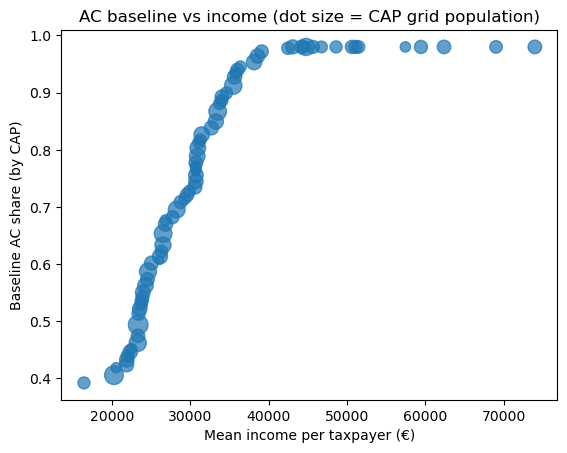

In [32]:
size = 200 * np.sqrt(cap_sub["pop_cap"] / cap_sub["pop_cap"].max())
size = np.clip(size, 10, None)

ax = cap_sub.plot.scatter(x="inc_mean", y="ac_cap_baseline", s=size, alpha=0.7)
ax.set_xlabel("Mean income per taxpayer (€)")
ax.set_ylabel("Baseline AC share (by CAP)")
ax.set_title("AC baseline vs income (dot size = CAP grid population)")

**Current CAP AC Coverage on CLIMADA GRID**

In [33]:
# building baseline AC coverage raster on the CLIMADA grid from CAP-level values 
# baseline AC coverage_map from CAP

# making a (cap_id, cap5) table from the polygons used to rasterize
cap_ref_lut = cap_ref[["cap_id","cap5"]].astype({"cap_id": int, "cap5": str}).copy()

# joining CAP-level baseline AC shares (computed earlier) onto cap_ids via cap5
# Result: one row per cap_id with its AC baseline
lut_df = (cap_ref_lut.merge(
            cap_stats[["cap5","ac_cap_baseline"]].assign(cap5=lambda d: d["cap5"].astype(str)),
            on="cap5", how="left")
         )

# if any cap_id has no stats, filling with city mean so we never leave holes
lut_df["ac_cap_baseline"] = lut_df["ac_cap_baseline"].fillna(float(ac_city)).astype("float32")

# building lookup array (indexable by cap_id) 
# ac_lut[i] = AC share for CAP with cap_id == i (NaN at ids we don't use)
max_id = int(lut_df["cap_id"].max())
ac_lut = np.full(max_id + 1, np.nan, dtype="float32")
ac_lut[lut_df["cap_id"].to_numpy()] = lut_df["ac_cap_baseline"].to_numpy()

# assigning AC to pixels: index the LUT where cap_on_ref>0; NaN elsewhere
coverage_map = np.full(ref_data.shape, np.nan, dtype="float32")
coverage_map[CAP_PIX] = ac_lut[cap_on_ref[CAP_PIX]]

# how much of pop lies in pixels that received a CAP value?
# if missing, filling valid-city pixels with the city mean
pop_city   = float(np.nansum(pop_on_ref[CITY_MASK]))
pop_on_cap = float(np.nansum(pop_on_ref[CAP_PIX]))
print(f"Pop coverage by CAP raster: {pop_on_cap/pop_city:.2%}")
if pop_on_cap < 0.999 * pop_city:
    coverage_map = np.where(CITY_MASK & ~CAP_PIX, float(ac_city), coverage_map)
    
# re-calibrating to hit the target pop-weighted mean via a mean-preserving stretch
m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_on_ref > 0)
city_mean_pw = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) /
                     np.nansum(pop_on_ref[m_city]))
print(f"[QA] City pop-w mean on grid: {city_mean_pw:.3f} (target {ac_city:.3f})")

Pop coverage by CAP raster: 100.00%
[QA] City pop-w mean on grid: 0.724 (target 0.724)


[QA] City pop-w mean from CAP agg: 0.724 (target 0.724)
[QA] City pop-w mean (CITY_MASK): 0.724 (target 0.724)


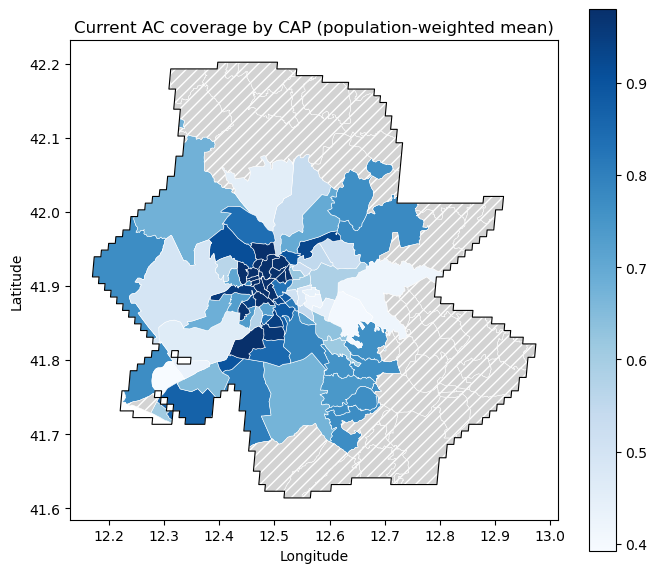


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.392,"17,485.161",39.216
1,53,00133,0.406,"104,346.731",40.580
2,52,00132,0.419,"9,058.825",41.880
3,88,00172,0.424,"35,387.854",42.398
4,48,00126,0.433,"37,270.786",43.254
5,87,00171,0.440,"21,520.389",43.956
6,86,00169,0.446,"34,904.343",44.636
7,103,00188,0.452,"11,031.125",45.195
8,67,00148,0.462,"71,563.741",46.212
9,93,00177,0.474,"27,361.908",47.449


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,99,00184,0.980,"24,342.991",98.000
1,108,00195,0.980,"18,091.153",98.000
2,78,00161,0.980,"21,326.934",98.000
3,101,00186,0.980,"24,992.352",98.000
4,71,00153,0.980,"32,566.941",98.000
5,111,00198,0.980,"27,986.802",98.000
6,105,00191,0.980,"24,873.101",98.000
7,56,00136,0.980,"30,156.225",98.000
8,107,00193,0.980,"9,688.623",98.000
9,63,00144,0.980,"72,118.238",98.000


In [40]:
import matplotlib as plt 
import matplotlib.pyplot as plt

# AC coverage by CAP (population-weighted), map + checks 

# mask on climada grid
valid = CAP_PIX

# grid to CAP population-weighted coverage
df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[valid].ravel().astype(int),
    "pop":    pop_on_ref[valid].ravel().astype(float),
    "cov":    coverage_map[valid].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

# pop-weighted average helper (returns NaN if weight sum is 0)
def wavg(g):
    w = g["pop"].to_numpy(dtype=float)
    x = g["cov"].to_numpy(dtype=float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

# aggregating per CAP
# ac_cov_pw: pop weighted mean AC coverage in each cap
# pop_cap: total modeled pop in CAP
# ac_min/med/max: distrib diagnostics within CAP
cap_pw   = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
cap_pop  = df_capgrid.groupby("cap_id", as_index=False)["pop"].sum().rename(columns={"pop":"pop_cap"})
cap_disp = (df_capgrid.groupby("cap_id")
            .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                 ac_max=("cov","max"), n_pix=("cov","size"))
            .reset_index())

# one tidy CAP table w coverage, pop and diagnostics
cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left").merge(cap_disp, on="cap_id", how="left")

# joining back to CAP polygons 
cap_map = cap_4326.merge(cap_cov, on="cap_id", how="left")

# back-aggregate to city pop weighted mean from CAP grid
cov_city_check = float(np.nansum(df_capgrid["cov"] * df_capgrid["pop"]) / np.nansum(df_capgrid["pop"]))
print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {ac_city:.3f})")

cov_city_all = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {ac_city:.3f})")

# plot 
ax = fua.to_crs("EPSG:4326").boundary.plot(edgecolor="black", facecolor="none", linewidth=0.8, figsize=(7,6))
cap_map.to_crs("EPSG:4326").plot(
    ax=ax, column="ac_cov_pw", cmap="Blues", legend=True,
    edgecolor="white", linewidth=0.4,
    missing_kwds={"color":"lightgray","edgecolor":"white","hatch":"///","label":"No data"}
)
ax.set_title("Current AC coverage by CAP (population-weighted mean)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.figure.tight_layout(); plt.show()

# tables: lowest / highest coverage CAPs
tbl = (cap_map[["cap_id","cap5","ac_cov_pw","pop_cap"]]
       .dropna(subset=["ac_cov_pw"])
       .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
       .sort_values("ac_pct"))

print("\nLowest-coverage CAPs:")
display(tbl.head(10).reset_index(drop=True))

print("Highest-coverage CAPs:")
display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))

In [41]:
# consistency checks

# pixels we actually painted from CAPs
valid = CAP_PIX

df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[valid].ravel().astype(int),
    "pop":    pop_on_ref[valid].ravel().astype(float),
    "cov":    coverage_map[valid].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

def wavg(g):
    w = g["pop"].to_numpy(dtype=float)
    x = g["cov"].to_numpy(dtype=float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

cap_pw  = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
cap_pop = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
           .sum().rename(columns={"pop":"pop_cap"}))
cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left")

# per-CAP value on the grid should match the CAP table value
cap_join = (cap_cov
            .merge(cap_ref[["cap_id","cap5"]], on="cap_id", how="left")
            .merge(cap_stats[["cap5","ac_cap_baseline"]], on="cap5", how="left"))

diff = np.abs(cap_join["ac_cov_pw"] - cap_join["ac_cap_baseline"])
err_cap = float(np.nanmax(diff)) if np.any(np.isfinite(diff)) else 0.0
print("Max per-CAP diff (grid vs table):", f"{err_cap:.3e}")

# grid-level bounds respected
m_city = CITY_MASK & np.isfinite(coverage_map)
print("Min/Max coverage on grid:",
      float(np.nanmin(coverage_map[m_city])),
      float(np.nanmax(coverage_map[m_city])))

# how much population is at the floor/cap? (over city pixels with AC values)
w = np.where(m_city, pop_on_ref, 0.0)
at_floor = np.isclose(coverage_map, ac_min, atol=1e-6)
at_cap   = np.isclose(coverage_map, ac_max, atol=1e-6)
print("Pop share at floor:", float(np.nansum(w*at_floor)/np.nansum(w)))
print("Pop share at cap:  ", float(np.nansum(w*at_cap)/np.nansum(w)))

# pop-weighted city mean from grid (should be close to target)
print("Grid pop-weighted mean:",
      float(np.nansum(coverage_map[m_city]*pop_on_ref[m_city]) /
            np.nansum(pop_on_ref[m_city])))

Max per-CAP diff (grid vs table): 2.643e-08
Min/Max coverage on grid: 0.39215677976608276 0.9800000190734863
Pop share at floor: 0.0
Pop share at cap:   0.15142353805523667
Grid pop-weighted mean: 0.7240000033248386


**Little note/question here: quite a lot at the CAP, but I tried to decrease the s of the logistic function and to modify the min/max, doesn't do much... I think by construction a lot are at the CAP. Problem?**

In [42]:
# building table: one row per CAP with income rank + grid pop
# we restrict to CAPs that actually have modeled population (>0) on the CLIMADA grid
cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0, ["cap_id","cap5","p_inc","pop_cap"]]
             .rename(columns={"pop_cap":"pop_cap_grid", "p_inc":"rank_key"})
)

sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","rank_key","pop_cap_grid"]]
       .sort_values("rank_key")   # still ascending: poorer first
       .reset_index(drop=True))

## AC Policy

some notes on following code:
- we rank CAPs by income but we cumulate the WorldPop pop, not the taxpayers anymore
- New policy!! 

**Catch-up policy** : 70% AC coverage for 50% poorest by CAP income rank with uniform efficacy : 0.3 and age-varying efficacy (an efficacy per age bucket): this needs **calibration**

In [73]:
# ADAPTATION CELL (target 50% of CAP-pop) 
import numpy as np
import pandas as pd

# helper: population-weighted mean on the grid 
def popw_mean(arr, mask=None):
    m = np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if mask is not None:
        m &= mask
    w = pop_on_ref[m]
    x = arr[m]
    return float(np.nansum(x*w) / np.nansum(w)) if np.any(m) else np.nan

# helper: CAP population-weighted mean from a grid raster over valid pixels
def cap_popw_mean_from(arr, valid_mask, name):
    m = valid_mask & np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if not np.any(m):
        return pd.DataFrame(columns=["cap_id", name])

    df = pd.DataFrame({
        "cap_id": cap_on_ref[m].ravel().astype(int),
        name:     arr[m].ravel().astype(float),
        "w":      pop_on_ref[m].ravel().astype(float),
    })
    out = (df.groupby("cap_id")
             .apply(lambda g: float(np.sum(g[name]*g["w"]) / np.sum(g["w"]))
                              if g["w"].sum() > 0 else np.nan)
             .reset_index(name=name))
    return out

# build selector input, anchored to the grid universe 
# cap_stats already contains: cap_id, cap5, inc_rank_base (clipped income), pop_cap (grid pop by CAP)
# keeping only CAPs with modeled population on the CLIMADA grid
if "p_inc" not in cap_stats.columns:
    cap_stats["p_inc"] = weighted_percentile_rank(
        cap_stats["inc_rank_base"].to_numpy(),
        cap_stats["pop_cap"].to_numpy()
    ).clip(1e-3, 1-1e-3)
    
cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0,
                  ["cap_id","cap5","inc_rank_base","p_inc","pop_cap"]]
             .rename(columns={"pop_cap": "pop_cap_grid"})
             .assign(cap_id=lambda d: d["cap_id"].astype(int),
                     pop_cap_grid=lambda d: d["pop_cap_grid"].astype(float))
             .reset_index(drop=True)
)

# Target (50% by grid population, poorest first) 
X_SHARE = 0.50     # target share of CAP-population (on CAP_PIX)
TARGET  = 0.70     # catch-up AC coverage (fraction)
AC_LO, AC_HI = ac_min, ac_max

# sort poorer -> richer by the rank base used everywhere else
sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","inc_rank_base","p_inc","pop_cap_grid"]]
       .sort_values("inc_rank_base")
       .reset_index(drop=True))

# cumulative population share (grid universe == CAP_PIX)
total_pop = float(sel["pop_cap_grid"].sum())
if total_pop <= 0:
    raise ValueError("No grid population in CAP universe (CAP_PIX). Check pop_on_ref / CAP_PIX masks.")

sel["cum_pop"]   = sel["pop_cap_grid"].cumsum()
sel["cum_share"] = sel["cum_pop"] / total_pop

# choosing cutoff closest to 50% (cap granularity can’t hit 50% exactly unless by chance)
cum = sel["cum_share"].to_numpy()
idx_hi = int(np.searchsorted(cum, X_SHARE, side="left"))
idx_hi = min(max(idx_hi, 0), len(sel)-1)
share_hi = float(cum[idx_hi])
share_lo = float(cum[idx_hi-1]) if idx_hi > 0 else 0.0

# pick whichever is closer to X_SHARE
use_hi = (abs(share_hi - X_SHARE) <= abs(share_lo - X_SHARE))
cut_idx = idx_hi if use_hi else (idx_hi - 1)

target_ids = sel.loc[:cut_idx, "cap_id"].astype(int).to_numpy()
target_ids = np.array(sorted(set(target_ids)), dtype=int)

# diagnostics
num = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, target_ids)]))
den = float(np.nansum(pop_on_ref[CAP_PIX]))
share = num / den if den > 0 else np.nan
print(f"Selection share (grid, cap_id-based): {share:.2%} "
      f"(X_SHARE={100*X_SHARE:.0f}%, lo={100*share_lo:.2f}%, hi={100*share_hi:.2f}%, picked={'hi' if use_hi else 'lo'})")

# applying policy at CAP level and paint to grid 
# table keyed by cap_id to avoid cap5<->cap_id roundtrips later
cap_tbl = (cap_ref[["cap_id","cap5"]].drop_duplicates()
           .merge(cap_stats[["cap5","ac_cap_baseline"]], on="cap5", how="left"))

cap_tbl["is_target"] = np.isin(cap_tbl["cap_id"].to_numpy(), target_ids)
cap_tbl["ac_cap_policy"] = np.where(
    cap_tbl["is_target"],
    np.maximum(cap_tbl["ac_cap_baseline"], TARGET),
    cap_tbl["ac_cap_baseline"]
).clip(AC_LO, AC_HI)

# LUTs
max_id = int(cap_ref["cap_id"].max())
ac_lut_base   = np.full(max_id + 1, np.nan, dtype="float32")
ac_lut_policy = np.full_like(ac_lut_base, np.nan)

idx = cap_tbl["cap_id"].astype(int).to_numpy()
ac_lut_base[idx]   = cap_tbl["ac_cap_baseline"].astype("float32").to_numpy()
ac_lut_policy[idx] = cap_tbl["ac_cap_policy"].astype("float32").to_numpy()

# filling any missing policy with base, and missing base with city mean
nan_pol = np.isnan(ac_lut_policy)
ac_lut_policy[nan_pol] = ac_lut_base[nan_pol]
nan_base = np.isnan(ac_lut_base)
ac_lut_base[nan_base] = float(ac_city)

# paint to grid in the CAP universe
coverage_base   = np.full(ref_data.shape, np.nan, dtype="float32")
coverage_policy = np.full_like(coverage_base, np.nan)
inside_cap_haz = CAP_PIX  # == (cap_on_ref>0) & CITY_MASK
coverage_base[inside_cap_haz]   = ac_lut_base[cap_on_ref[inside_cap_haz]]
coverage_policy[inside_cap_haz] = ac_lut_policy[cap_on_ref[inside_cap_haz]]

CAP_MASK = CAP_PIX & np.isfinite(coverage_base) & np.isfinite(coverage_policy)

# Checks
# City means
mean_uplift_pp = 100 * (popw_mean(coverage_policy, CAP_MASK) - popw_mean(coverage_base, CAP_MASK))
print(f"City AC baseline (pop-w, CAP_PIX): {popw_mean(coverage_base, CAP_MASK):.3f}")
print(f"City AC policy   (pop-w, CAP_PIX): {popw_mean(coverage_policy, CAP_MASK):.3f}")
print(f"Δ mean (pp): {mean_uplift_pp:.2f}")

# Policy correctness checks
TOL = 1e-6  

# LUT-level: targeted CAPs lifted to >= TARGET (unless already above), never reduced
targ_mask_tbl = np.isin(cap_tbl["cap_id"].to_numpy(), target_ids)
base = cap_tbl["ac_cap_baseline"].to_numpy()
pol  = cap_tbl["ac_cap_policy"].to_numpy()

v1 = (targ_mask_tbl & (base + TOL < TARGET) & (pol + TOL < TARGET))
v2 = (targ_mask_tbl & (base >= TARGET - TOL) & (pol + TOL < base - 1e-12))
print("LUT violations (should be 0, 0):", int(v1.sum()), int(v2.sum()))

# grid-aggregated by CAP: targeted CAPs pop-w mean >= TARGET (within tol)
cap_pw_base = cap_popw_mean_from(coverage_base,   CAP_MASK, "base")
cap_pw_pol  = cap_popw_mean_from(coverage_policy, CAP_MASK, "pol")
targ_df = pd.DataFrame({"cap_id": target_ids}).assign(is_target=True)

cap_pw = (cap_pw_base.merge(cap_pw_pol, on="cap_id", how="outer")
                    .merge(targ_df, on="cap_id", how="left")
                    .fillna({"is_target": False}))

bad_targeted = cap_pw[ cap_pw["is_target"] & (cap_pw["pol"] + TOL < TARGET) ]
ok_targeted  = cap_pw[ cap_pw["is_target"] & (cap_pw["pol"] + TOL >= TARGET) ]
print(f"Targeted CAPs meeting target (within tol): {len(ok_targeted)}/{int(cap_pw['is_target'].sum())}")

Selection share (grid, cap_id-based): 49.82% (X_SHARE=50%, lo=49.82%, hi=51.12%, picked=lo)
City AC baseline (pop-w, CAP_PIX): 0.724
City AC policy   (pop-w, CAP_PIX): 0.798
Δ mean (pp): 7.43
LUT violations (should be 0, 0): 0 0
Targeted CAPs meeting target (within tol): 34/34


In [44]:
# diagnostics: p_inc for the targeted set
sel["is_target"] = False
sel.loc[:cut_idx, "is_target"] = True

target_view = (sel.loc[sel["is_target"],
                       ["cap_id","cap5","inc_rank_base","p_inc","pop_cap_grid","cum_share"]]
                 .assign(p_inc_pct=lambda d: (100*d["p_inc"]).round(1),
                         pop_k=lambda d: (d["pop_cap_grid"]/1000).round(1))
              )

print("Targeted CAPs (poorest first) – showing first/last 10 with p_inc:")
try:
    display(pd.concat([target_view.head(10), target_view.tail(10)]).reset_index(drop=True))
except NameError:
    print(pd.concat([target_view.head(10), target_view.tail(10)]).reset_index(drop=True))

p_boundary = float(sel.loc[cut_idx, "p_inc"])
share_boundary = float(sel.loc[cut_idx, "cum_share"])
print(f"Boundary p_inc ≈ {p_boundary:.3f} (~{p_boundary*100:.1f}th pct by people); "
      f"cum. share at boundary = {share_boundary:.2%}")

# what if we used p_inc <= boundary as the selection rule?
ids_by_pinc = (cap_income_id.loc[
                    (cap_income_id["p_inc"] <= p_boundary) &
                    (cap_income_id["pop_cap_grid"] > 0),
                    "cap_id"]
               .astype(int).unique())
num2 = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, ids_by_pinc)]))
den  = float(np.nansum(pop_on_ref[CAP_PIX]))
print(f"Selection share if using p_inc<=boundary: {num2/den:.2%} (vs grid-anchored {share:.2%})")

Targeted CAPs (poorest first) – showing first/last 10 with p_inc:


,cap_id,cap5,inc_rank_base,p_inc,pop_cap_grid,cum_share,p_inc_pct,pop_k
0,41,00119,"19,472.391",0.003,"17,485.161",0.007,0.300,17.500
1,53,00133,"20,239.128",0.027,"104,346.731",0.048,2.700,104.300
2,52,00132,"20,526.122",0.050,"9,058.825",0.051,5.000,9.100
3,88,00172,"21,838.697",0.058,"35,387.854",0.065,5.800,35.400
4,48,00126,"21,879.120",0.073,"37,270.786",0.080,7.300,37.300
5,87,00171,"21,986.438",0.084,"21,520.389",0.088,8.400,21.500
6,86,00169,"22,324.881",0.095,"34,904.343",0.102,9.500,34.900
7,103,00188,"22,460.978",0.104,"11,031.125",0.106,10.400,11.000
8,67,00148,"23,274.837",0.120,"71,563.741",0.134,12.000,71.600
9,93,00177,"23,305.890",0.140,"27,361.908",0.145,14.000,27.400


Boundary p_inc ≈ 0.495 (~49.5th pct by people); cum. share at boundary = 49.82%
Selection share if using p_inc<=boundary: 49.82% (vs grid-anchored 49.82%)


In [45]:
# CAP-level coverage table (baseline, policy, Δ) 
valid_b = CAP_MASK & np.isfinite(coverage_base)
valid_p = CAP_MASK & np.isfinite(coverage_policy)
cap_base = cap_popw_mean_from(coverage_base,   valid_b, "ac_base")
cap_pol  = cap_popw_mean_from(coverage_policy, valid_p, "ac_policy")
cap_cov  = (cap_base.merge(cap_pol, on="cap_id", how="outer")
                    .assign(delta=lambda d: d["ac_policy"] - d["ac_base"]))

cap_pop = (pd.DataFrame({"cap_id": cap_on_ref[CAP_MASK].ravel().astype(int),
                         "pop":    pop_on_ref[CAP_MASK].ravel().astype(float)})
           .groupby("cap_id", as_index=False)["pop"].sum()
           .rename(columns={"pop":"pop_cap"}))

cap_cov = (cap_cov.merge(cap_pop, on="cap_id", how="left")
                 .merge(cap_4326[["cap_id","cap5"]], on="cap_id", how="left"))

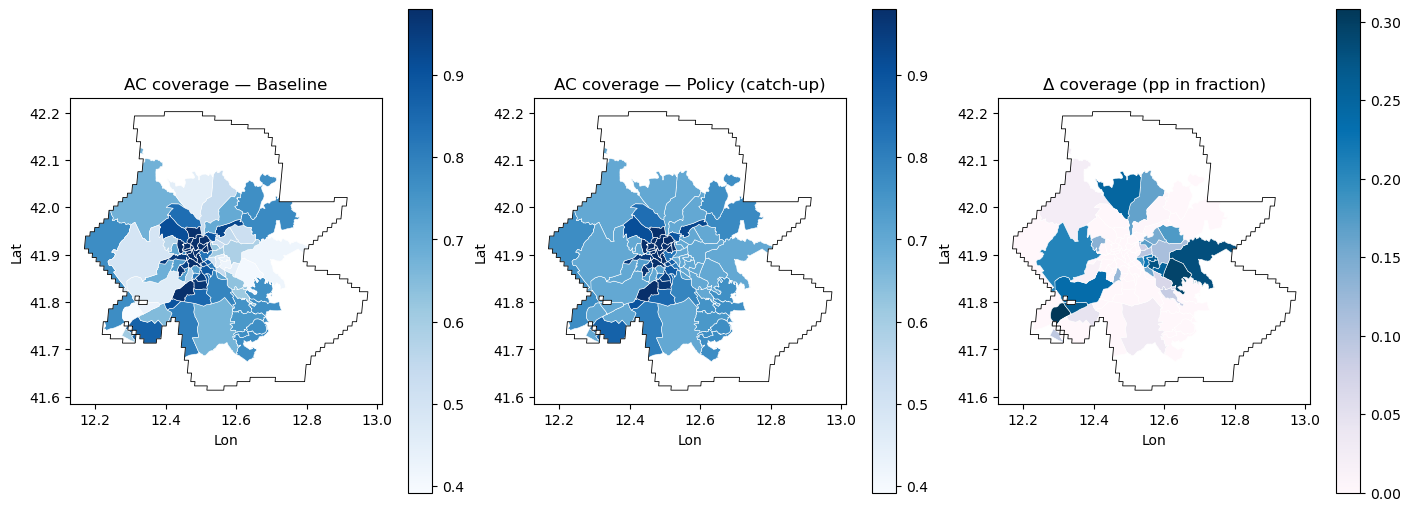

In [46]:
# maps: baseline, policy, delta (same plotting as before) 
cap_map = cap_4326.merge(cap_cov[["cap_id","ac_base","ac_policy","delta"]], on="cap_id", how="left")
vmin = float(np.nanmin([cap_cov["ac_base"].min(), cap_cov["ac_policy"].min()]))
vmax = float(np.nanmax([cap_cov["ac_base"].max(), cap_cov["ac_policy"].max()]))
fig, ax = plt.subplots(1,3, figsize=(14,5), constrained_layout=True)

fua.to_crs("EPSG:4326").boundary.plot(ax=ax[0], color="k", lw=0.6)
cap_map.to_crs("EPSG:4326").plot(ax=ax[0], column="ac_base", cmap="Blues",
                                 vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True)
ax[0].set_title("AC coverage — Baseline"); ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

fua.to_crs("EPSG:4326").boundary.plot(ax=ax[1], color="k", lw=0.6)
cap_map.to_crs("EPSG:4326").plot(ax=ax[1], column="ac_policy", cmap="Blues",
                                 vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True)
ax[1].set_title("AC coverage — Policy (catch-up)"); ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

fua.to_crs("EPSG:4326").boundary.plot(ax=ax[2], color="k", lw=0.6)
dv = float(np.nanmax(np.abs(cap_map["delta"])))
cap_map.to_crs("EPSG:4326").plot(ax=ax[2], column="delta", cmap="PuBu",
                                 vmin=0.0, vmax=dv, edgecolor="white", lw=0.4, legend=True)
ax[2].set_title("Δ coverage (pp in fraction)"); ax[2].set_xlabel("Lon"); ax[2].set_ylabel("Lat")
plt.show()

In [47]:
# tables: top/bottom Δ by CAP 
tbl = (cap_cov.dropna(subset=["delta"])
              .assign(ac_base_pct=lambda d: 100*d["ac_base"],
                      ac_policy_pct=lambda d: 100*d["ac_policy"],
                      delta_pp=lambda d: 100*d["delta"])
              .sort_values("delta_pp", ascending=False))
print("Top Δcoverage CAPs:")
display(tbl[["cap5","ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]].head(10).reset_index(drop=True))
print("Bottom (or zero) Δcoverage CAPs:")
display(tbl[["cap5","ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]].tail(10).sort_values("delta_pp").reset_index(drop=True))

Top Δcoverage CAPs:


,cap5,ac_base_pct,ac_policy_pct,delta_pp,pop_cap
0,00119,39.216,70.000,30.784,"17,485.161"
1,00133,40.580,70.000,29.420,"104,346.731"
2,00132,41.880,70.000,28.120,"9,058.825"
3,00172,42.398,70.000,27.602,"35,387.854"
4,00126,43.254,70.000,26.746,"37,270.786"
5,00171,43.956,70.000,26.044,"21,520.389"
6,00169,44.636,70.000,25.364,"34,904.343"
7,00188,45.195,70.000,24.805,"11,031.125"
8,00148,46.212,70.000,23.788,"71,563.741"
9,00177,47.449,70.000,22.551,"27,361.908"


Bottom (or zero) Δcoverage CAPs:


,cap5,ac_base_pct,ac_policy_pct,delta_pp,pop_cap
0,00145,81.780,81.780,0.000,"14,603.407"
1,00147,94.528,94.528,0.000,"15,728.025"
2,00149,73.469,73.469,0.000,"33,073.160"
3,00151,97.200,97.200,0.000,"25,336.304"
4,00152,93.970,93.970,0.000,"26,312.384"
5,00153,98.000,98.000,0.000,"32,566.941"
6,00013,76.445,76.445,0.000,"9,041.909"
7,00161,98.000,98.000,0.000,"21,326.934"
8,00162,97.776,97.776,0.000,"19,608.258"
9,00199,98.000,98.000,0.000,"24,055.478"


In [48]:
# some checks 
# sets at each stage
caps_csv   = set(inc_agg["cap5"].astype(str))
caps_shp   = set(cap_4326["cap5"].astype(str))                      # after FUA clip
caps_rast  = set(cap_ref["cap5"].astype(str))                       # after reprojection (same as caps_shp)
ids_on_grid = set(np.unique(cap_on_ref[cap_on_ref > 0]).astype(int))
caps_labeled = set(cap_ref.loc[cap_ref["cap_id"].isin(ids_on_grid), "cap5"].astype(str))

# CAPs with any pixel under CITY_MASK 
ids_cap_pix = set(np.unique(cap_on_ref[CAP_PIX]).astype(int))
caps_cap_pix = set(cap_ref.loc[cap_ref["cap_id"].isin(ids_cap_pix), "cap5"].astype(str))

# CAPs with >0 modeled pop in CAP_PIX
df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":    pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]
pop_by_cap = (df_capgrid.groupby("cap_id")["pop"].sum()
              .rename("pop_cap").reset_index())
caps_poppos = set(
    cap_ref.merge(pop_by_cap, on="cap_id", how="left")
           .query("pop_cap > 0")["cap5"].astype(str)
)

# buckets
missing_in_shapes_or_outside_fua = sorted(caps_csv - caps_shp)
in_shapes_but_no_labeled_pixels  = sorted(caps_shp - caps_labeled)
labeled_but_not_in_CITY_MASK     = sorted(caps_labeled - caps_cap_pix)
in_CAP_PIX_but_zero_population   = sorted(caps_cap_pix - caps_poppos)

print("CSV CAPs:", len(caps_csv))
print("After FUA clip (polygons):", len(caps_shp))
print("Labeled on grid (any pixels):", len(caps_labeled))
print("In CAP_PIX (city mask & labeled):", len(caps_cap_pix))
print(">0 population in CAP_PIX:", len(caps_poppos))
print()

print("Missing (CSV but not in shapes/FUA):", len(missing_in_shapes_or_outside_fua), missing_in_shapes_or_outside_fua[:10])
print("No labeled pixels (resolution / all_touched=False):", len(in_shapes_but_no_labeled_pixels), in_shapes_but_no_labeled_pixels[:10])
print("Only outside CITY_MASK/hazard or pop==0 area:", len(labeled_but_not_in_CITY_MASK), labeled_but_not_in_CITY_MASK[:10])
print("Zero modeled pop in CAP_PIX:", len(in_CAP_PIX_but_zero_population), in_CAP_PIX_but_zero_population[:10])

CSV CAPs: 72
After FUA clip (polygons): 118
Labeled on grid (any pixels): 82
In CAP_PIX (city mask & labeled): 81
>0 population in CAP_PIX: 81

Missing (CSV but not in shapes/FUA): 0 []
No labeled pixels (resolution / all_touched=False): 36 ['00010', '00015', '00018', '00019', '00020', '00024', '00029', '00030', '00031', '00033']
Only outside CITY_MASK/hazard or pop==0 area: 1 ['00072']
Zero modeled pop in CAP_PIX: 0 []


Super important to understand why:
- In my income CSV there are 72 rows of 72 CAP with incomes data
- But then shapefile + FUA clip contains all CAP zones that intersect the FUA (metro area), not just the Comune di Roma → 118 CAPs. Many of those extra CAPs are the suburban/postal zones that start with 000xx (typical around Rome).
- After rasterization, 36 of those polygons don’t catch a grid cell at the resolution (all_touched=False) → “No labeled pixels”. One more has pixels but none in CITY_MASK (outside hazard or pop_on_ref==0)

**Municipi**

[QA] City (grid) base=0.724 vs sum-over-Municipi=0.724
[QA] City (grid) pol =0.798 vs sum-over-Municipi=0.798

Top/bottom Municipi by Δ (policy - baseline), pp


,muni_id,muni_name,ac_base_pct,ac_policy_pct,delta_pp,pop_muni,users_base,users_policy
0,6,Municipio Roma VI,41.939,70.000,28.061,"130,848.193","54,875.992","91,593.733"
1,5,Municipio Roma V,50.624,70.192,19.568,"175,631.614","88,912.407","123,279.725"
2,11,Municipio Roma XI,55.028,70.879,15.852,"119,537.335","65,778.702","84,727.235"
3,4,Municipio Roma IV,58.193,71.126,12.933,"170,982.495","99,500.427","121,613.071"
4,13,Municipio Roma XIII,66.122,77.675,11.552,"131,022.061","86,634.626","101,770.786"
5,10,Municipio Roma X,67.338,76.152,8.814,"221,222.410","148,967.305","168,465.732"
6,14,Municipio Roma XIV,73.073,80.577,7.503,"158,029.184","115,477.288","127,334.725"
7,7,Municipio Roma VII,70.186,76.004,5.818,"248,257.701","174,242.208","188,686.416"
8,12,Municipio Roma XII,77.351,82.257,4.906,"131,970.543","102,081.123","108,555.345"
9,3,Municipio Roma III,75.008,78.022,3.014,"148,266.814","111,211.736","115,680.085"


,muni_id,muni_name,ac_base_pct,ac_policy_pct,delta_pp,pop_muni,users_base,users_policy
0,1,Municipio Roma I,94.987,94.987,0.000,"179,310.302","170,321.590","170,321.590"
1,2,Municipio Roma II,95.352,95.504,0.152,"161,208.331","153,715.900","153,961.075"
2,9,Municipio Roma IX,85.759,86.261,0.502,"219,039.174","187,846.009","188,944.564"
3,8,Municipio Roma VIII,83.805,84.902,1.097,"113,726.641","95,308.661","96,556.452"
4,15,Municipio Roma XV,84.440,87.312,2.872,"98,417.632","83,103.439","85,930.211"
5,3,Municipio Roma III,75.008,78.022,3.014,"148,266.814","111,211.736","115,680.085"
6,12,Municipio Roma XII,77.351,82.257,4.906,"131,970.543","102,081.123","108,555.345"
7,7,Municipio Roma VII,70.186,76.004,5.818,"248,257.701","174,242.208","188,686.416"
8,14,Municipio Roma XIV,73.073,80.577,7.503,"158,029.184","115,477.288","127,334.725"
9,10,Municipio Roma X,67.338,76.152,8.814,"221,222.410","148,967.305","168,465.732"


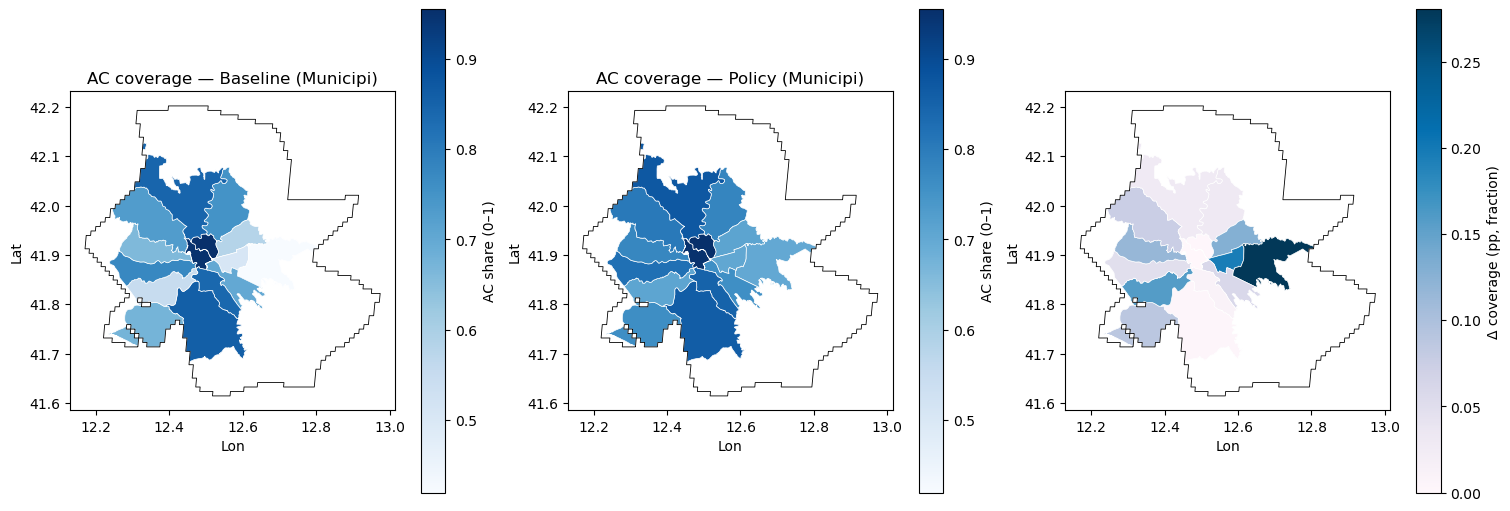

In [52]:
# Municipio level AC COVERAGE: baseline & policy (pop-weighted)

import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import rasterize

# municipio label raster on the CLIMADA grid
if "muni_on_ref" not in globals():
    regions_ref = regions.to_crs(ref_meta["crs"])  # regions = Municipi + outside bucket (id==0)
    # from notebook 5
    shapes = [(geom, int(mid)) for geom, mid in zip(regions_ref.geometry, regions_ref["muni_id"])]
    muni_on_ref = rasterize(
        shapes=shapes,
        out_shape=ref_data.shape,
        transform=ref_meta["transform"],
        fill=-1, dtype="int32", all_touched=False
    )

# pop-weighted aggregation of AC baseline/policy to Municipi
# using the CAP universe where coverage
mask = CAP_MASK & (muni_on_ref >= 0)

df = pd.DataFrame({
    "muni_id":  muni_on_ref[mask].ravel().astype(int),           # includes 0 = outside Municipi
    "pop":      pop_on_ref[mask].ravel().astype(float),
    "base":     coverage_base[mask].ravel().astype(float),
    "policy":   coverage_policy[mask].ravel().astype(float),
})

def _wavg(x, w):
    w = np.asarray(w, float); x = np.asarray(x, float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

muni_cov = (df.groupby("muni_id")
              .apply(lambda g: pd.Series({
                  "ac_base":   _wavg(g["base"],   g["pop"]),
                  "ac_policy": _wavg(g["policy"], g["pop"]),
                  "pop_muni":  float(g["pop"].sum())
              }))
              .reset_index())

muni_cov["delta_pp"] = 100.0 * (muni_cov["ac_policy"] - muni_cov["ac_base"])

# attaching names and keeping a readable name for id==0
muni_cov = (muni_cov
            .rename(columns={"ac_base": "ac_base_muni",
                             "ac_policy": "ac_policy_muni"})
            .assign(delta=lambda d: d["ac_policy_muni"] - d["ac_base_muni"]))

# recreaing dfm and users/pop groupbys from the same df we just built
dfm = df.copy()  # df has muni_id, pop, base, policy (on CAP_MASK ∩ valid municipio)
dfm["users_base"]   = dfm["base"]   * dfm["pop"]
dfm["users_policy"] = dfm["policy"] * dfm["pop"]

muni_pop   = dfm.groupby("muni_id", as_index=False)["pop"].sum().rename(columns={"pop":"pop_muni"})
muni_users = (dfm.groupby("muni_id", as_index=False)
                .agg(users_base=("users_base","sum"),
                     users_policy=("users_policy","sum")))

# attach users and names to muni_cov 
muni_cov = (muni_cov
            .merge(muni_users, on="muni_id", how="left")
            .merge(muni[["muni_id","muni_name"]], on="muni_id", how="left"))

# readable name 
muni_cov["muni_name"] = muni_cov["muni_name"].fillna("Fuori Municipi (FUA)")

# Checks: city means in the same universe (CAP_PIX) should match the grid pop-w mean 
city_base  = popw_mean(coverage_base,   CAP_MASK)
city_pol   = popw_mean(coverage_policy, CAP_MASK)
agg_base   = float(np.nansum(muni_cov["ac_base_muni"]   * muni_cov["pop_muni"]) / np.nansum(muni_cov["pop_muni"]))
agg_policy = float(np.nansum(muni_cov["ac_policy_muni"] * muni_cov["pop_muni"]) / np.nansum(muni_cov["pop_muni"]))
print(f"[QA] City (grid) base={city_base:.3f} vs sum-over-Municipi={agg_base:.3f}")
print(f"[QA] City (grid) pol ={city_pol:.3f} vs sum-over-Municipi={agg_policy:.3f}")

# tables
muni_only = muni_cov[muni_cov["muni_id"] > 0].copy()
muni_only["ac_base_pct"]   = 100*muni_only["ac_base_muni"]
muni_only["ac_policy_pct"] = 100*muni_only["ac_policy_muni"]
muni_only["delta_pp"]      = 100*muni_only["delta"]

print("\nTop/bottom Municipi by Δ (policy - baseline), pp")
top = muni_only.sort_values("delta_pp", ascending=False).head(10)
bot = muni_only.sort_values("delta_pp", ascending=True).head(10)
display(top[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp","pop_muni","users_base","users_policy"]].reset_index(drop=True))
display(bot[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp","pop_muni","users_base","users_policy"]].reset_index(drop=True))

# Maps (Municipi only)
muni_map = (muni[["muni_id","muni_name","geometry"]]
            .merge(muni_only, on="muni_id", how="left"))

# common scale across baseline ad policy 
vmin = float(np.nanmin(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))
vmax = float(np.nanmax(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))

fig, ax = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)

fua.to_crs("EPSG:4326").boundary.plot(ax=ax[0], color="k", lw=0.6)
muni_map.to_crs("EPSG:4326").plot(
    ax=ax[0], column="ac_base_muni", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
    legend_kwds={"label":"AC share (0–1)"}
)
ax[0].set_title("AC coverage — Baseline (Municipi)")

fua.to_crs("EPSG:4326").boundary.plot(ax=ax[1], color="k", lw=0.6)
muni_map.to_crs("EPSG:4326").plot(
    ax=ax[1], column="ac_policy_muni", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
    legend_kwds={"label":"AC share (0–1)"}
)
ax[1].set_title("AC coverage — Policy (Municipi)")

dv = float(np.nanmax(np.abs(muni_map["delta"])))
fua.to_crs("EPSG:4326").boundary.plot(ax=ax[2], color="k", lw=0.6)
muni_map.to_crs("EPSG:4326").plot(
    ax=ax[2], column="delta", cmap="PuBu",
    vmin=0.0, vmax=dv, edgecolor="white", lw=0.5, legend=True,
    legend_kwds={"label":"Δ coverage (pp, fraction)"}
)
for a in ax: a.set_xlabel("Lon"); a.set_ylabel("Lat")
plt.show()

**Mortality with AC: uniform efficacy vs age-varying efficacy**

In [53]:
# prep coverage rasters for mortality 
# using same city universe as before
mask_city = CITY_MASK

# baseline city mean on the CAP universe
ac_city = float(popw_mean(coverage_base, CAP_MASK))

In [54]:
def deaths_with_ac(I_grid, coverage_grid, eff=0.30):
    """
    Total deaths (all ages) for one event grid with AC reducing vulnerability.
    MDD_adj = MDD * (1 - eff * coverage), clipped to [0,1].
    """
    m = CITY_MASK & np.isfinite(I_grid)
    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city)  # should already be filled, but safe
    deaths = np.zeros_like(I_grid, dtype=float)
    for age_lbl, f in age_ifs.items():
        mdd = np.interp(I_grid, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
        mult = np.clip(1.0 - eff * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

In [55]:
# age-varying efficacy by 3 buckets 
def deaths_with_ac_varage(I_grid, coverage_grid, eff_base=0.30,
                          eff_by_bucket={"<15":0.20, "15-64":0.30, "65+":0.40}):
    m = CITY_MASK & np.isfinite(I_grid)
    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city)
    deaths = np.zeros_like(I_grid, dtype=float)

    def _eff_for(age_lbl):
        for pat, val in eff_by_bucket.items():
            if pat in str(age_lbl):
                return float(val)
        return float(eff_base)

    for age_lbl, f in age_ifs.items():
        mdd = np.interp(I_grid, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
        eff_a = _eff_for(age_lbl)
        mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

In [58]:
# Example: 2050 event like before
year_focus = 2050
i_ev = list(H.event_id).index(year_focus)
I_2050 = _row_to_grid(H.intensity, i_ev, ref_data.shape)

In [63]:
# Deaths: baseline vs policy (uniform efficacy)
EFF_UNIFORM = 0.30
deaths_base_uni   = deaths_with_ac(I_2050, coverage_base,   eff=EFF_UNIFORM)
deaths_policy_uni = deaths_with_ac(I_2050, coverage_policy, eff=EFF_UNIFORM)

In [64]:
# Deaths: baseline vs policy (age-varying efficacy)
EFF_BUCKETS = {"<15":0.20, "15-64":0.30, "65+":0.40}
deaths_base_age   = deaths_with_ac_varage(I_2050, coverage_base,   eff_by_bucket=EFF_BUCKETS)
deaths_policy_age = deaths_with_ac_varage(I_2050, coverage_policy, eff_by_bucket=EFF_BUCKETS)

In [65]:
# City totals (on the consistent mask)
d_avo_uni = deaths_base_uni - deaths_policy_uni
d_avo_age = deaths_base_age - deaths_policy_age
city_total_avo_uni = float(np.nansum(d_avo_uni[CITY_MASK]))
city_total_avo_age = float(np.nansum(d_avo_age[CITY_MASK]))

In [66]:
# Municipio aggregation (avoided deaths and per 100k) for both efficacy specs 
def muni_agg_avoided(d_avo_grid):
    rows = []
    ids = np.unique(muni_on_ref[np.isfinite(ref_data) & (muni_on_ref >= 0)])  # includes 0
    id2name = dict(zip(muni["muni_id"], muni["muni_name"])); id2name[0] = "Fuori Municipi (FUA)"
    for mid in ids.astype(int):
        m = (muni_on_ref == mid) & CITY_MASK
        if not np.any(m): 
            continue
        pop_m = sum(float(np.nansum(age_on_ref[a][m])) for a in age_ifs)
        d_avo_m = float(np.nansum(d_avo_grid[m]))
        rows.append({"muni_id": mid, "muni_name": id2name.get(mid, str(mid)),
                     "avoided": d_avo_m,
                     "avo_per_100k": (d_avo_m/pop_m*1e5) if pop_m>0 else np.nan})
    return pd.DataFrame(rows)

df_muni_avo_uni = muni_agg_avoided(d_avo_uni)
df_muni_avo_age = muni_agg_avoided(d_avo_age)

# now summing across municipios match the city totals computed on all pixels
print("Sum of municipio avoided vs city total — uniform:",
      df_muni_avo_uni["avoided"].sum(), city_total_avo_uni)
print("Sum of municipio avoided vs city total — age-varying:",
      df_muni_avo_age["avoided"].sum(), city_total_avo_age)

Sum of municipio avoided vs city total — uniform: 58.36942243807265 58.36942243807265
Sum of municipio avoided vs city total — age-varying: 76.52620747148299 76.52620747148299


In [67]:
# change in coverage per municipio (pop-weighted), using the same df used for muni_cov (includes id==0)
id2name = dict(zip(muni["muni_id"], muni["muni_name"]))
id2name[0] = "Fuori Municipi (FUA)"

df_muni_delta = (
    df.assign(delta=df["policy"] - df["base"])
      .groupby("muni_id", as_index=False)
      .apply(lambda g: pd.Series({
          "ΔAC_pw":       float(np.average(g["delta"], weights=g["pop"])) if g["pop"].sum() > 0 else np.nan,
          "pop_cap_mask": float(g["pop"].sum()),
      }))
      .reset_index(drop=True)
)

df_muni_delta["muni_name"] = df_muni_delta["muni_id"].map(id2name)

# City Δ from municipios (same pixels as CAP_MASK) will now match the map
city_dpp_from_muni = 100.0 * (
    (df_muni_delta["ΔAC_pw"] * df_muni_delta["pop_cap_mask"]).sum()
    / df_muni_delta["pop_cap_mask"].sum()
)
city_dpp_from_map = 100.0 * popw_mean(coverage_policy - coverage_base, mask=CAP_MASK)
print("City ΔAC (pp) from municipios vs map:", city_dpp_from_muni, city_dpp_from_map)

City ΔAC (pp) from municipios vs map: 7.434209438291815 7.434209438291814


In [68]:
# joining with avoided-deaths (uniform) to get avoided per pp uplift
MIN_PP = 0.5

muni_eff_uni = (df_muni_avo_uni.merge(df_muni_delta, on=["muni_id","muni_name"], how="left")
                            .assign(delta_pp=lambda d: 100*d["ΔAC_pw"],
                                    avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"]>0, d["delta_pp"], np.nan),
                                    flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

muni_eff_age = (df_muni_avo_age.merge(df_muni_delta, on=["muni_id","muni_name"], how="left")
                            .assign(delta_pp=lambda d: 100*d["ΔAC_pw"],
                                    avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"]>0, d["delta_pp"], np.nan),
                                    flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

print("Top municipios (avoided per pp uplift) — uniform EFF:")
display(muni_eff_uni.sort_values("avoided_per_pp", ascending=False)
        [["muni_id","muni_name","avoided","avo_per_100k","delta_pp","avoided_per_pp"]]
        .head(10).reset_index(drop=True))

print("Top municipios (avoided per pp uplift) — age-varying EFF:")
display(muni_eff_age.sort_values("avoided_per_pp", ascending=False)
        [["muni_id","muni_name","avoided","avo_per_100k","delta_pp","avoided_per_pp"]]
        .head(10).reset_index(drop=True))

Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,2,Municipio Roma II,0.133,0.083,0.152,0.876
1,7,Municipio Roma VII,4.171,1.680,5.818,0.717
2,9,Municipio Roma IX,0.338,0.154,0.502,0.674
3,10,Municipio Roma X,5.774,2.610,8.814,0.655
4,5,Municipio Roma V,12.479,7.105,19.568,0.638
5,4,Municipio Roma IV,7.106,4.156,12.933,0.549
6,3,Municipio Roma III,1.526,1.029,3.014,0.506
7,6,Municipio Roma VI,11.754,8.983,28.061,0.419
8,11,Municipio Roma XI,6.089,5.094,15.852,0.384
9,12,Municipio Roma XII,1.870,1.417,4.906,0.381


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,2,Municipio Roma II,0.175,0.108,0.152,1.150
1,7,Municipio Roma VII,5.467,2.202,5.818,0.940
2,9,Municipio Roma IX,0.443,0.202,0.502,0.883
3,10,Municipio Roma X,7.568,3.421,8.814,0.859
4,5,Municipio Roma V,16.366,9.319,19.568,0.836
5,4,Municipio Roma IV,9.318,5.450,12.933,0.721
6,3,Municipio Roma III,2.002,1.350,3.014,0.664
7,6,Municipio Roma VI,15.411,11.778,28.061,0.549
8,11,Municipio Roma XI,7.984,6.679,15.852,0.504
9,12,Municipio Roma XII,2.452,1.858,4.906,0.500


In [69]:
# checks
city_dpp_from_muni = 100 * float(
    (df_muni_delta["ΔAC_pw"] * df_muni_delta["pop_cap_mask"]).sum()
    / df_muni_delta["pop_cap_mask"].sum()
)

city_dpp_from_map = 100 * popw_mean(coverage_policy - coverage_base, mask=CAP_MASK)
print("City ΔAC (pp) from municipios vs map:", city_dpp_from_muni, city_dpp_from_map)

print("Sum of municipio avoided vs city total — uniform:",
      df_muni_avo_uni["avoided"].sum(), city_total_avo_uni)
print("Sum of municipio avoided vs city total — age-varying:",
      df_muni_avo_age["avoided"].sum(), city_total_avo_age)

City ΔAC (pp) from municipios vs map: 7.434209438291815 7.434209438291814
Sum of municipio avoided vs city total — uniform: 58.36942243807265 58.36942243807265
Sum of municipio avoided vs city total — age-varying: 76.52620747148299 76.52620747148299


More **avoided deaths** with the age-varying efficacy

**Shift in IF**

In [70]:
import numpy as np
import matplotlib.pyplot as plt

age_keys = ["<15", "15-64", "65+"]

# pop-weighted helper over the analysis domain (CAP_MASK so coverage defined)
DOM_MASK = CAP_MASK & np.isfinite(pop_on_ref)
w = np.where(DOM_MASK, pop_on_ref, 0.0)

def wavg_multiplier(coverage, eff):
    mult = np.clip(1.0 - eff * np.where(DOM_MASK, coverage, 0.0), 0.0, 1.0)
    return float(np.nansum(mult * w) / np.nansum(w)) if np.nansum(w) > 0 else np.nan

[Uniform eff=0.30] pop-w multiplier: baseline=0.783, policy=0.760, policy/base=0.972


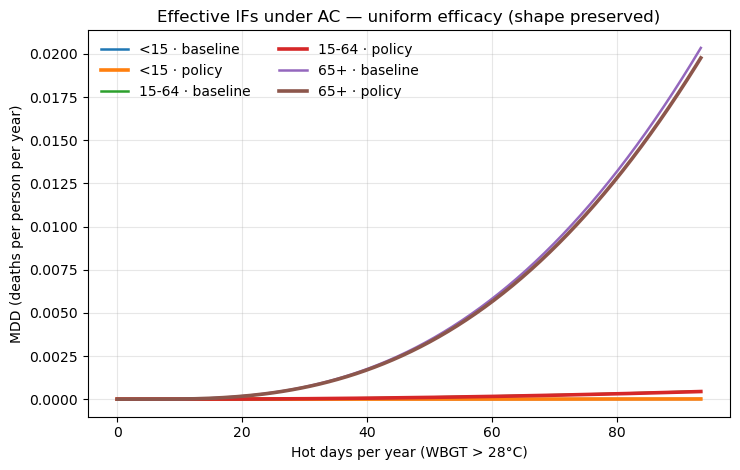

In [71]:
EFF_UNIFORM = 0.30

m_base_uni   = wavg_multiplier(coverage_base,   EFF_UNIFORM)
m_policy_uni = wavg_multiplier(coverage_policy, EFF_UNIFORM)

print(f"[Uniform eff={EFF_UNIFORM:.2f}] pop-w multiplier: baseline={m_base_uni:.3f}, policy={m_policy_uni:.3f}, "
      f"policy/base={m_policy_uni/m_base_uni:.3f}")

plt.figure(figsize=(7.5, 4.8))
for k in age_keys:
    f = age_ifs[k]
    x = f.intensity.astype(float)
    y0 = f.mdd.astype(float)
    # vertical shift (scaling) of IFs by the pop-weighted multiplier
    y_base   = y0 * m_base_uni
    y_policy = y0 * m_policy_uni
    plt.plot(x, y_base,   linewidth=1.8, label=f"{k} · baseline")
    plt.plot(x, y_policy, linewidth=2.6, label=f"{k} · policy")
plt.xlabel("Hot days per year (WBGT > 28°C)")
plt.ylabel("MDD (deaths per person per year)")
plt.title("Effective IFs under AC — uniform efficacy (shape preserved)")
plt.grid(alpha=0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

[Age-varying eff] pop-w multipliers:
    <15: baseline=0.855, policy=0.840, policy/base=0.983
  15-64: baseline=0.783, policy=0.760, policy/base=0.972
    65+: baseline=0.710, policy=0.681, policy/base=0.958


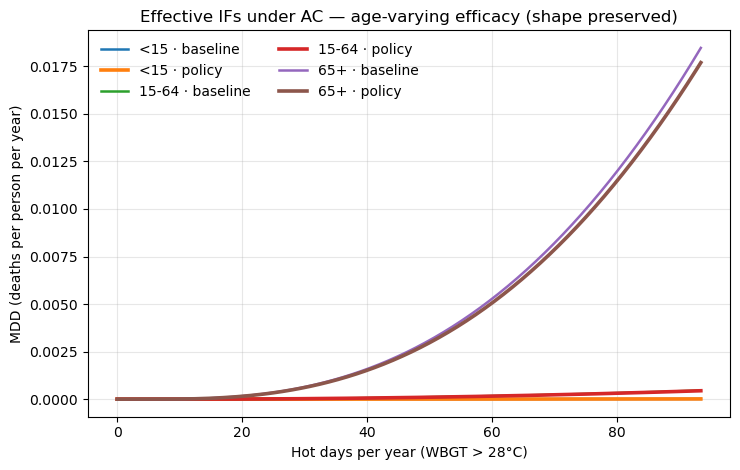

In [72]:
EFF_BUCKETS = {"<15":0.20, "15-64":0.30, "65+":0.40}

# pop-weighted multipliers per age (same coverage, different eff by age)
m_base_age   = {age: wavg_multiplier(coverage_base,   EFF_BUCKETS.get(age, EFF_UNIFORM)) for age in age_keys}
m_policy_age = {age: wavg_multiplier(coverage_policy, EFF_BUCKETS.get(age, EFF_UNIFORM)) for age in age_keys}

print("[Age-varying eff] pop-w multipliers:")
for age in age_keys:
    mb, mp = m_base_age[age], m_policy_age[age]
    print(f"  {age:>5}: baseline={mb:.3f}, policy={mp:.3f}, policy/base={mp/mb:.3f}")

plt.figure(figsize=(7.5, 4.8))
for k in age_keys:
    f = age_ifs[k]
    x = f.intensity.astype(float)
    y0 = f.mdd.astype(float)
    y_base   = y0 * m_base_age[k]
    y_policy = y0 * m_policy_age[k]
    plt.plot(x, y_base,   linewidth=1.8, label=f"{k} · baseline")
    plt.plot(x, y_policy, linewidth=2.6, label=f"{k} · policy")
plt.xlabel("Hot days per year (WBGT > 28°C)")
plt.ylabel("MDD (deaths per person per year)")
plt.title("Effective IFs under AC — age-varying efficacy (shape preserved)")
plt.grid(alpha=0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

Conversely to before and to the CLIMADA method, here scaling is continuous, pixel by pixel => we don't create bins and discretise the cap specific scalings into a few categories => for pixel p in CAP c and age a : we multiply the impact function for the age a x by (1- efficacy of a * coverage of p) => we have one IF per CAP*age but we don't instantiate thousands of separate IF objects => we multiply by the local factor inside deaths_with_ac(...). 

> **Notes:**
> - In the uniform efficacy, all ages are scaled down by the same proportion but it looks like only 65 + moves because the 65+ IF is much larger so the % shrink is more obvious visually. 
> - In the second case - age-varying efficacy - the scale down is stronger but especially because of the fact that the efficacy for the 65+ is stronger than the uniform efficacy
> - Careful: the scaling looks small because it's the INCREMENTAL change: baseline (current AC) vs post-policy